# 시계열 데이터 예시

In [50]:
# ============================================
# 주가 시계열 데이터 확장 + RNN 학습용 데이터 생성
# ============================================
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------
# 1. 주가 시계열 데이터 생성 (120일치)
# --------------------------------------------
np.random.seed(42)
days = 120  # 약 6개월 (거래일 기준)

# 시작 가격
start_price = 50000

# 주가 = 상승 추세 + 사인 주기 패턴 + 랜덤 노이즈
timesteps = np.arange(days)
trend = timesteps * 50                          # 하루 평균 50원씩 상승 추세
cycle = 3000 * np.sin(timesteps * 0.1)          # 주기적 등락 (사인 패턴)
noise = np.random.randn(days) * 500             # 랜덤 변동성

stock_prices = start_price + trend + cycle + noise

# 전일 대비 변화량
changes = np.diff(stock_prices, prepend=stock_prices[0])




In [51]:
# --------------------------------------------
# 2. 데이터 확인 (처음 10일)
# --------------------------------------------
print("=" * 55)
print("주가 시퀀스 (처음 10일)")
print("=" * 55)
for i in range(10):
    price = stock_prices[i]
    change = changes[i]
    sign = "+" if change >= 0 else ""
    arrow = "↑" if change > 0 else ("↓" if change < 0 else " ")
    print(f"  Day {i+1:3d}: {price:,.0f}원 {arrow} ({sign}{change:,.0f})")
print(f"  ... (총 {days}일)")
print()



주가 시퀀스 (처음 10일)
  Day   1: 50,248원   (+0)
  Day   2: 50,280원 ↑ (+32)
  Day   3: 51,020원 ↑ (+739)
  Day   4: 51,798원 ↑ (+778)
  Day   5: 51,251원 ↓ (-547)
  Day   6: 51,571원 ↑ (+320)
  Day   7: 52,784원 ↑ (+1,212)
  Day   8: 52,666원 ↓ (-117)
  Day   9: 52,317원 ↓ (-349)
  Day  10: 53,071원 ↑ (+754)
  ... (총 120일)



# 시계열 데이터 시각화

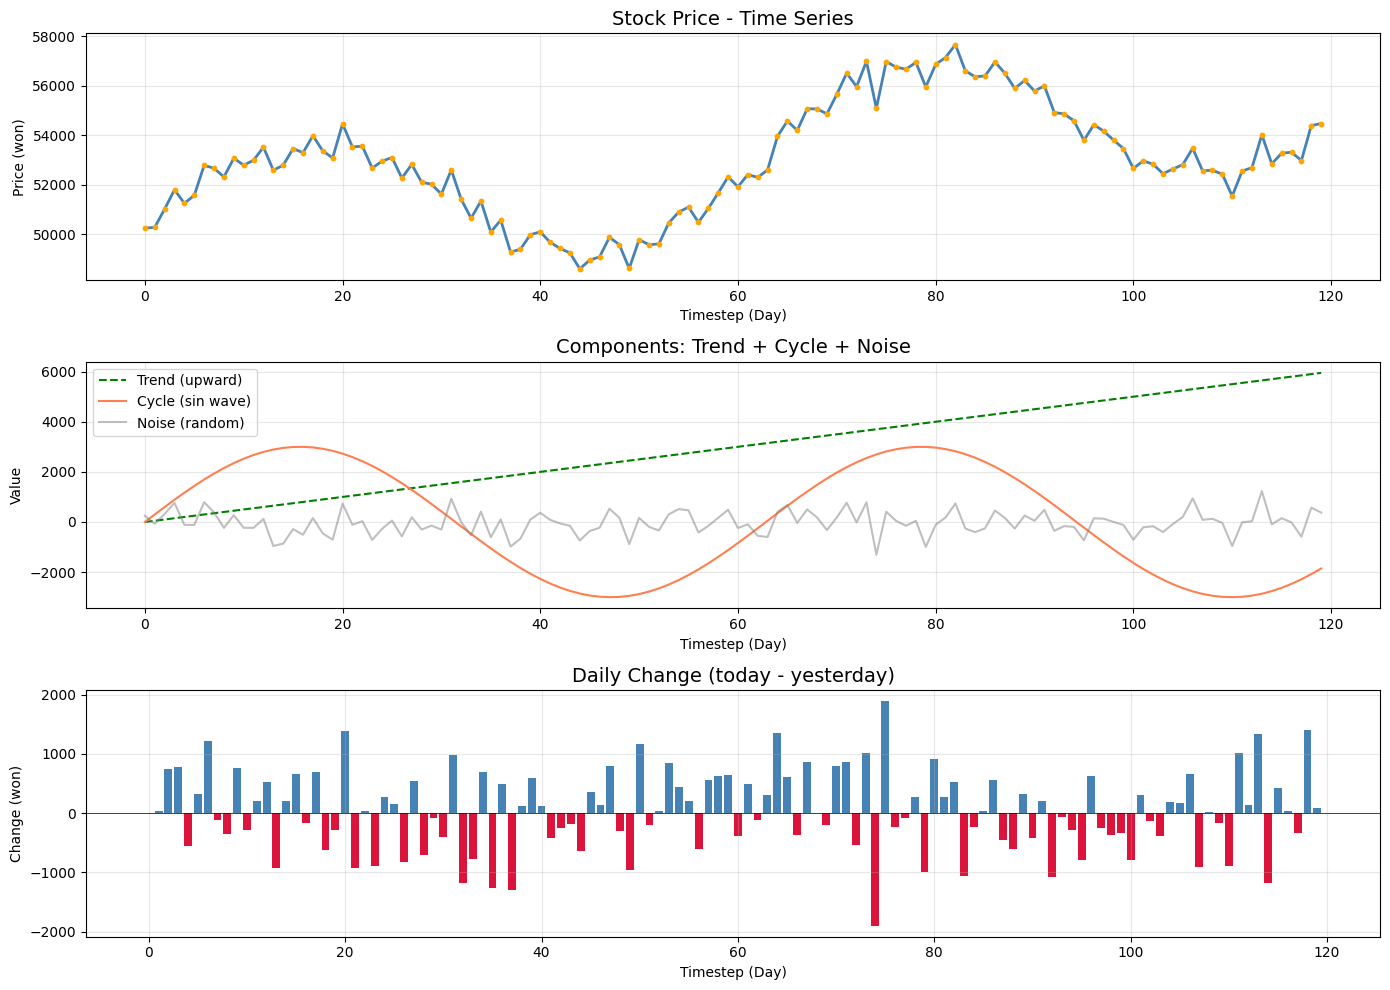

In [52]:
# --------------------------------------------
# 3. 시각화
# --------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# 3-1) 주가 흐름
axes[0].plot(timesteps, stock_prices, color='steelblue', linewidth=2)
axes[0].scatter(timesteps, stock_prices, color='orange', s=10, zorder=5)
axes[0].set_title("Stock Price - Time Series", fontsize=14)
axes[0].set_xlabel("Timestep (Day)")
axes[0].set_ylabel("Price (won)")
axes[0].grid(True, alpha=0.3)

# 3-2) 주가 구성 요소 분해
axes[1].plot(timesteps, trend, label='Trend (upward)', linestyle='--', color='green')
axes[1].plot(timesteps, cycle, label='Cycle (sin wave)', linestyle='-', color='coral')
axes[1].plot(timesteps, noise, label='Noise (random)', linestyle='-', color='gray', alpha=0.5)
axes[1].set_title("Components: Trend + Cycle + Noise", fontsize=14)
axes[1].set_xlabel("Timestep (Day)")
axes[1].set_ylabel("Value")
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# 3-3) 전일 대비 변화량
colors = ['crimson' if c < 0 else 'steelblue' for c in changes]
axes[2].bar(timesteps, changes, color=colors, width=0.8)
axes[2].axhline(y=0, color='black', linewidth=0.5)
axes[2].set_title("Daily Change (today - yesterday)", fontsize=14)
axes[2].set_xlabel("Timestep (Day)")
axes[2].set_ylabel("Change (won)")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



# 4. RNN 학습용 데이터 구조 미리보기

In [53]:
# --------------------------------------------
# 4. RNN 학습용 데이터 구조 미리보기
# --------------------------------------------
print("=" * 55)
print("RNN 학습용 데이터 구조 (window_size=5)")
print("=" * 55)
window_size = 5
print(f"  입력(X): 과거 {window_size}일 주가 → 출력(y): 다음 1일 주가")
print()
for i in range(3):
    x = stock_prices[i:i+window_size]
    y = stock_prices[i+window_size]
    x_str = [f"{v:,.0f}" for v in x]
    print(f"  샘플 {i+1}: X={x_str} → y={y:,.0f}")
print(f"  ...")
print(f"  총 샘플 수: {days - window_size}개")
print()
print("→ RNN은 과거 5일 패턴을 보고 내일 주가를 예측!")

RNN 학습용 데이터 구조 (window_size=5)
  입력(X): 과거 5일 주가 → 출력(y): 다음 1일 주가

  샘플 1: X=['50,248', '50,280', '51,020', '51,798', '51,251'] → y=51,571
  샘플 2: X=['50,280', '51,020', '51,798', '51,251', '51,571'] → y=52,784
  샘플 3: X=['51,020', '51,798', '51,251', '51,571', '52,784'] → y=52,666
  ...
  총 샘플 수: 115개

→ RNN은 과거 5일 패턴을 보고 내일 주가를 예측!


# imdb 영화 평론

In [54]:
import tensorflow
from tensorflow.keras.datasets import imdb
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((25000,), (25000,), (25000,), (25000,))

In [ ]:
X_train[0]

In [55]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
X_train_pad= pad_sequences(X_train, maxlen=80, truncating='post', padding='post')
X_test_pad= pad_sequences(X_test, maxlen=80, truncating='post', padding='post') 

# DNN
embedding 층
dense 층 - 은닉
dense 층 - 출력

In [56]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, Flatten

model = Sequential()

# Embedding: 단어 인덱스 → 의미 벡터로 변환
model.add(Embedding(input_dim=10000, output_dim=32, input_length=80))
model.add(Flatten())

# 은닉층
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

# 출력층
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()


/home/ubuntu/miniforge3/envs/dl_env/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# DNN 모델 학습

In [57]:
# ============================================
# 모델 컴파일 + 학습
# ============================================
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train_pad, y_train,
                    epochs=10,
                    batch_size=256,
                    validation_split=0.2)


Epoch 1/10


I0000 00:00:1775021426.166716   20886 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_74654__.13


72/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5257 - loss: 0.6890

I0000 00:00:1775021427.695770   20885 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_74654__.13


79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.5863 - loss: 0.6639 - val_accuracy: 0.7594 - val_loss: 0.5048
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8292 - loss: 0.3884 - val_accuracy: 0.8006 - val_loss: 0.4293
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9464 - loss: 0.1591 - val_accuracy: 0.7810 - val_loss: 0.5651
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9917 - loss: 0.0355 - val_accuracy: 0.7812 - val_loss: 0.8191
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9986 - loss: 0.0077 - val_accuracy: 0.7772 - val_loss: 0.9772
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9992 - loss: 0.0036 - val_accuracy: 0.7778 - val_loss: 1.0718
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9997 - loss: 0.0019 - val_accuracy: 0.7814 - val_loss: 1.1382
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9996 - loss: 0.0021 - val_accuracy: 0.7784 - val_loss: 1.1805
Ep

# DNN 테스트 평가

In [58]:
# ============================================
# 테스트 평가
# ============================================
test_loss, test_acc = model.evaluate(X_test_pad, y_test)
print(f"테스트 정확도: {test_acc:.4f}")
print(f"테스트 손실  : {test_loss:.4f}")


782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7650 - loss: 1.4096
테스트 정확도: 0.7650
테스트 손실  : 1.4096


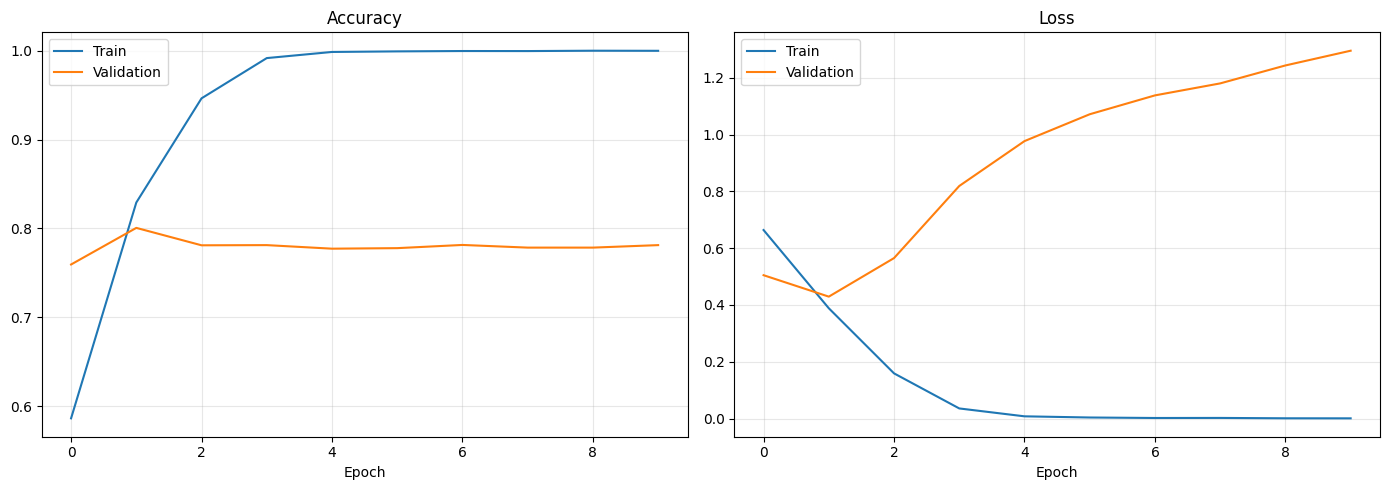

In [59]:
# ============================================
# 학습 과정 시각화
# ============================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 정확도
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 손실
axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# 학습 과정 시각화

# RNN

In [60]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense

model = Sequential([
    Input(shape=(80,)),
    Embedding(input_dim=10000, output_dim=32),
    SimpleRNN(64),
    Dense(2, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 80, 32)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 326,338 (1.24 MB)

 Trainable params: 326,338 (1.24 MB)

 Non-trainable params: 0 (0.00 B)

# 패딩 처리

In [61]:
# 패딩 처리
from tensorflow.keras.preprocessing.sequence import pad_sequences
X_train_pad = pad_sequences(X_train, maxlen=80, truncating='post', padding='post')
X_test_pad = pad_sequences(X_test, maxlen=80, truncating='post', padding='post')


# 모델 학습

In [62]:
%%time
history = model.fit(X_train_pad, y_train, epochs=10, batch_size=200, validation_split=0.2)


Epoch 1/10


I0000 00:00:1775021456.727457   20885 dot_merger.cc:481] Merging Dots in computation: sequential_7_1_simple_rnn_2_1_while_body_83561_grad_83715_const_0__.21.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1775021456.727578   20885 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_84160__.24


100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.5419 - loss: 0.6883 - val_accuracy: 0.5098 - val_loss: 0.6931
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6510 - loss: 0.6392 - val_accuracy: 0.6780 - val_loss: 0.5918
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8352 - loss: 0.3804 - val_accuracy: 0.7872 - val_loss: 0.4636
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9277 - loss: 0.1936 - val_accuracy: 0.7606 - val_loss: 0.5618
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9774 - loss: 0.0805 - val_accuracy: 0.7868 - val_loss: 0.6381
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9923 - loss: 0.0327 - val_accuracy: 0.7582 - val_loss: 0.7097
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9974 - loss: 0.0153 - val_accuracy: 0.7710 - val_loss: 0.8242
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9990 - loss: 0.0079 - val_accuracy: 0.773

# 테스트 평가

In [63]:
# 테스트 평가
test_loss, test_acc = model.evaluate(X_test_pad, y_test)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss    : {test_loss:.4f}")


782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7490 - loss: 0.9955
Test Accuracy: 0.7490
Test Loss    : 0.9955


# 학습 과정 시각화

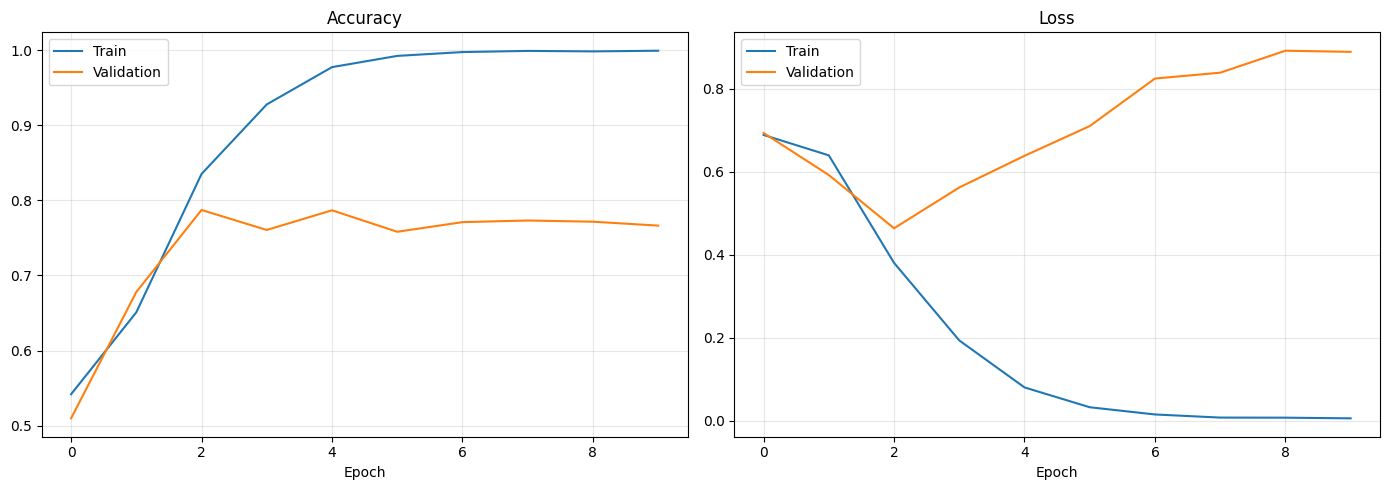

In [64]:
# 학습 과정 시각화
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 정확도
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 손실
axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# SimpleRNN Train/Val Acc 저장 (결과 요약표용)
rnn_train_acc = round(history.history['accuracy'][-1], 4)
rnn_val_acc = round(history.history['val_accuracy'][-1], 4)

# 1 LSTM 모델

In [65]:
# ============================================
# LSTM 모델 (IMDB 긍정/부정 분류)
# ============================================
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense

# 데이터 로드
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

# 패딩 처리 (pre 방식 적용)
X_train_pad = pad_sequences(X_train, maxlen=80, truncating='pre', padding='pre')
X_test_pad = pad_sequences(X_test, maxlen=80, truncating='pre', padding='pre')


# 2 모델 구성

In [66]:
# 모델 구성
model = Sequential([
    Input(shape=(80,)),
    Embedding(input_dim=10000, output_dim=32),
    LSTM(64),
    Dense(2, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 80, 32)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 344,962 (1.32 MB)

 Trainable params: 344,962 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

# 3 모델 학습

In [67]:
%%time
history = model.fit(X_train_pad, y_train, epochs=10, batch_size=200, validation_split=0.2)


Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7390 - loss: 0.5071 - val_accuracy: 0.8224 - val_loss: 0.3841
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8726 - loss: 0.3028 - val_accuracy: 0.8370 - val_loss: 0.3637
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9085 - loss: 0.2359 - val_accuracy: 0.8342 - val_loss: 0.4013
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9275 - loss: 0.1975 - val_accuracy: 0.8278 - val_loss: 0.4098
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9428 - loss: 0.1559 - val_accuracy: 0.8196 - val_loss: 0.4861
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9546 - loss: 0.1253 - val_accuracy: 0.8160 - val_loss: 0.5441
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9675 - loss: 0.0967 - val_accuracy: 0.8140 - val_loss: 0.6432
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9737 - loss: 0.0779 - val_accura

# 4 테스트 평가

In [68]:
# 테스트 평가
test_loss, test_acc = model.evaluate(X_test_pad, y_test)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss    : {test_loss:.4f}")


782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8065 - loss: 0.6890
Test Accuracy: 0.8065
Test Loss    : 0.6890


# 5 학습 과정 시각화

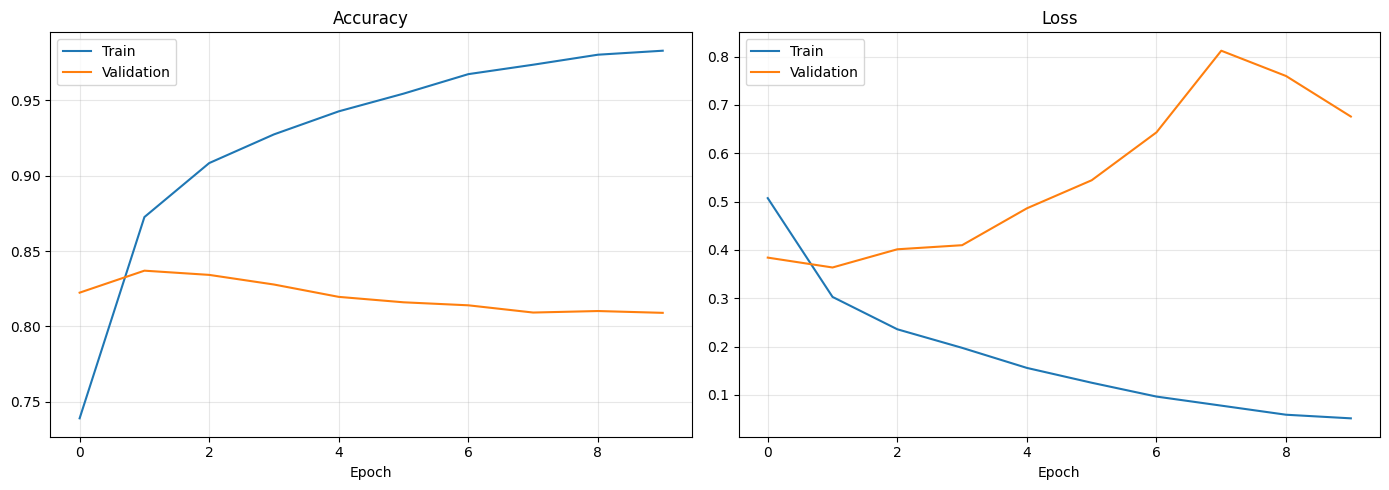

In [69]:
# 학습 과정 시각화
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 정확도
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 손실
axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 전체 실험 결과 요약

In [70]:
# ============================================
# 전체 실험 결과 요약
# ============================================
import pandas as pd

# LSTM history에서 Train Acc, Val Acc 가져오기
lstm_train_acc = round(history.history['accuracy'][-1], 4)
lstm_val_acc = round(history.history['val_accuracy'][-1], 4)
lstm_test_acc = 0.8000

results = {
    '실험': ['Step 1', 'Step 2', 'Step 3', 'Step 4'],
    '모델 구조': ['DNN', 'DNN + Embedding', 'SimpleRNN + Embedding', 'LSTM'],
    'Train Acc': [0.5100, 1.0000, rnn_train_acc, lstm_train_acc],
    'Val Acc': [0.5000, 0.7800, rnn_val_acc, lstm_val_acc],
    'Test Acc': [0.5000, 0.7800, 0.7482, lstm_test_acc],
    '특이사항': [
        '학습 실패, 랜덤 수준(50%)',
        '극단적 과적합, val_loss 상승',
        '훈련 100% 수렴, 테스트 급락',
        'padding=pre 적용, 성능 향상'
    ]
}

df = pd.DataFrame(results)
df = df.set_index('실험')
df

,모델 구조,Train Acc,Val Acc,Test Acc,특이사항
실험,,,,,
Step 1,DNN,0.5100,0.5000,0.5000,"학습 실패, 랜덤 수준(50%)"
Step 2,DNN + Embedding,1.0000,0.7800,0.7800,"극단적 과적합, val_loss 상승"
Step 3,SimpleRNN + Embedding,0.9992,0.7664,0.7482,"훈련 100% 수렴, 테스트 급락"
Step 4,LSTM,0.9830,0.8090,0.8000,"padding=pre 적용, 성능 향상"
